## Import Libraries

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## Feature Engineering

In [28]:
df = pd.read_csv ("../data/Predictive Maintenance Dataset.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [29]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Power proxy [W]"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)

df["Tool wear level"] = pd.cut(
    df["Tool wear [min]"],
    bins=[-1, 80, 160, 260],
    labels=["Low", "Medium", "High"]
)

## Modeling dataframe

In [30]:
model_df = df.copy()

model_df = model_df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

model_df = pd.get_dummies(
    model_df,
    columns=["Type", "Tool wear level"],
    drop_first=True,
    dtype=int
)

X = model_df.drop(columns=["Machine failure"])
y = model_df["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts(normalize=True) * 100)

X shape: (10000, 11)
y shape: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Power proxy [W],Type_L,Type_M,Tool wear level_Medium,Tool wear level_High
0,298.1,308.6,1551,42.8,0,10.5,6951.590560,0,1,0,0
1,298.2,308.7,1408,46.3,3,10.5,6826.722724,1,0,0,0
2,298.1,308.5,1498,49.4,5,10.4,7749.387543,1,0,0,0
3,298.2,308.6,1433,39.5,7,10.4,5927.504659,1,0,0,0
4,298.2,308.7,1408,40.0,9,10.5,5897.816608,1,0,0,0


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Testing target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64
Testing target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## Standardization

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Baseline

In [33]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

In [34]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print(classification_report(y_test, y_pred))

Accuracy: 0.9695
Precision: 0.6521739130434783
Recall: 0.22058823529411764
F1 Score: 0.32967032967032966
ROC-AUC: 0.926249847765193
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.65      0.22      0.33        68

    accuracy                           0.97      2000
   macro avg       0.81      0.61      0.66      2000
weighted avg       0.96      0.97      0.96      2000



## Confusion Matrix

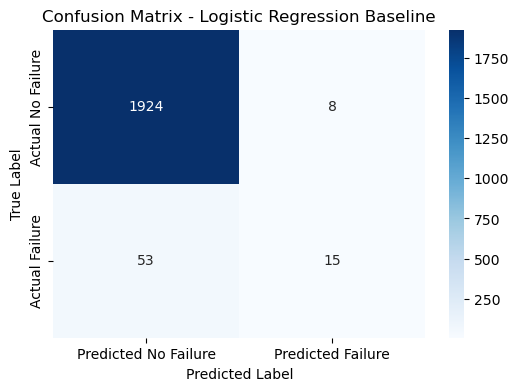

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Class Weight

In [39]:
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)
y_pred_proba_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)

print("Accuracy:", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall:", recall_balanced)
print("F1 Score:", f1_balanced)
print("ROC-AUC:", roc_auc_balanced)

print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.8555
Precision: 0.17595307917888564
Recall: 0.8823529411764706
F1 Score: 0.293398533007335
ROC-AUC: 0.9321261113140908
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1932
           1       0.18      0.88      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



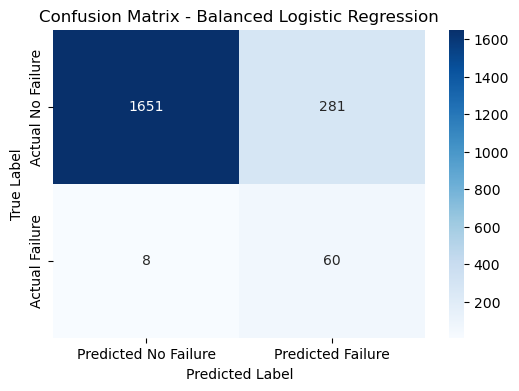

In [37]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Initial Modeling Findings

Two logistic regression models were trained as baseline models for binary machine failure prediction: a standard logistic regression model and a balanced logistic regression model.

The standard logistic regression model achieved high overall accuracy, but this result is misleading because the dataset is highly imbalanced. Only about 3.39% of the records represent machine failure cases. The model achieved a failure-class precision of approximately 0.65, but its failure-class recall was only about 0.22. This means the model was relatively conservative when predicting failures. When it predicted a failure, it was often correct, but it missed many actual failure cases.

The balanced logistic regression model used `class_weight="balanced"` to give more importance to the minority failure class during training. This significantly increased failure-class recall to approximately 0.88, meaning the model detected most actual failure cases. However, failure-class precision dropped to approximately 0.18, meaning the model produced many false alarms.

This result reveals an important predictive maintenance trade-off. A conservative model reduces false alarms but may miss real machine failures, while a more sensitive model detects more failures but may create unnecessary maintenance alerts. In a manufacturing environment, missing a real failure can lead to unplanned downtime, production delays, and higher maintenance costs. However, too many false alarms can also reduce trust in the system and increase unnecessary inspection workload.

Therefore, accuracy alone is not an appropriate evaluation metric for this project. Precision, recall, F1-score, confusion matrix, and ROC-AUC provide a more complete view of model performance. For predictive maintenance, recall is especially important because the cost of missing an actual failure may be high.

The next step is to compare these logistic regression baselines with tree-based models such as Random Forest. Random Forest may capture nonlinear relationships between operating variables more effectively, especially interactions among torque, rotational speed, tool wear, and temperature-related features. Later, threshold tuning and precision-recall analysis can also be used to better control the trade-off between false alarms and missed failures.